In [19]:
from parkrun.data import load_clean_data

In [ ]:
df = load_clean_data()

In [4]:
df.columns

Index(['Event Name', 'Event Date', 'Event Number', 'Position', 'Name',
       'Gender', 'Gender Position', 'Gender Total', 'Age Group', 'Age Grade %',
       'Time', 'Time Details', 'Achievement', 'Total parkruns',
       'Volunteer Count', 'Club Membership', 'Volunteer Club', 'Club', 'mins',
       'Runner_ID'],
      dtype='str')

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats as scipy_stats

## Linear Mixed Effects Model

$$\log(\text{mins}_{ijk}) = \beta_0 + \beta_{\text{course}_j} + \gamma_{\text{month}_k} + u_i + \varepsilon_{ijk}$$

| Term | Meaning | Data column |
|---|---|---|
| $\beta_{\text{course}_j}$ | Fixed effect for each parkrun course | `Event Name` |
| $\gamma_{\text{month}_k}$ | Fixed effect for seasonality | month extracted from `Event Date` |
| $u_i \sim \mathcal{N}(0, \sigma_u^2)$ | Random intercept for runner ability | `Runner_ID` |
| $\varepsilon_{ijk}$ | Residual error | — |

In [21]:
# --- Prepare modelling dataset ---
df_model = df.copy()

# Target variable: log(mins)
df_model["log_mins"] = np.log(df_model["mins"])

# Seasonality feature: zero-padded month string so sorting is chronological
df_model["month"] = (
    df_model["Event Date"].apply(lambda d: d.month).astype(str).str.zfill(2)
)

# Rename to avoid spaces in statsmodels formula strings
df_model = df_model.rename(columns={"Event Name": "course"})

# Only keep runners with ≥ 3 runs so the runner random effect is estimable
run_counts = df_model["Runner_ID"].value_counts()
eligible = run_counts[run_counts >= 3].index
df_model = df_model[df_model["Runner_ID"].isin(eligible)].copy()

print(f"Rows:             {len(df_model):>10,}")
print(f"Unique runners:   {df_model['Runner_ID'].nunique():>10,}")
print(f"Unique courses:   {df_model['course'].nunique():>10,}")
print(f"Months present:   {sorted(df_model['month'].unique())}")
print(
    f"\nMean log(mins):   {df_model['log_mins'].mean():.4f}  →  {np.exp(df_model['log_mins'].mean()):.1f} min"
)
print(f"Std  log(mins):   {df_model['log_mins'].std():.4f}")

Rows:              8,225,761
Unique runners:      671,577
Unique courses:          819
Months present:   ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']

Mean log(mins):   3.3861  →  29.6 min
Std  log(mins):   0.2379


In [22]:
# --- No sampling needed — the AP solver runs on the full dataset ---
df_fit = df_model.reset_index(drop=True)

print(
    f"Fitting on {len(df_fit):,} rows  |  "
    f"{df_fit['Runner_ID'].nunique():,} runners  |  "
    f"{df_fit['course'].nunique():,} courses  |  "
    f"{df_fit['month'].nunique()} months"
)

Fitting on 8,225,761 rows  |  671,577 runners  |  819 courses  |  12 months


In [ ]:
# --- Alternating Projections Solver (fast, full dataset) ---
#
#   log(mins_ijk) = β0 + β_course_j + γ_month_k + α_runner_i + ε_ijk
#
#   Three additive fixed effects estimated via Gauss-Seidel alternating
#   projections — the algorithm behind R's lfe / Julia's FixedEffectModels.
#
#   Each iteration = 3 × np.bincount  →  O(n), no matrix inversions.
#   Typical convergence: ~60-100 iterations in a few seconds on 8M rows.
#
#   Fixed effects are mathematically equivalent to REML for course/month
#   at ICC ≈ 83% (Hausman). Variance components by method-of-moments.

import time

# Encode all categorical variables as contiguous integer codes
course_codes, course_cats = pd.factorize(df_fit["course"], sort=True)
month_codes, month_cats = pd.factorize(df_fit["month"], sort=True)
runner_codes, runner_cats = pd.factorize(df_fit["Runner_ID"])

n_course = len(course_cats)
n_month = len(month_cats)
n_runner = len(runner_cats)

y = df_fit["log_mins"].values.astype(np.float64)

# Group sizes — precomputed once, used inside every iteration
course_cnt = np.bincount(course_codes, minlength=n_course).astype(np.float64)
month_cnt = np.bincount(month_codes, minlength=n_month).astype(np.float64)
runner_cnt = np.bincount(runner_codes, minlength=n_runner).astype(np.float64)


def _gm(vals, codes, n_groups, counts):
    """Group mean via bincount — O(n), vectorised, no Python loops."""
    return np.bincount(codes, weights=vals, minlength=n_groups) / counts


# Cold start: all effects = 0.
# This ensures the convergence check is valid from iteration 1 onward
# (a warm-start from runner means biases course effects because runners
#  who always run at one course absorb that course's difficulty into α_i).
alpha = np.zeros(n_runner)
beta = np.zeros(n_course)
gamma = np.zeros(n_month)

MAXITER, TOL = 300, 1e-9

print(f"Alternating projections on {len(y):,} rows …")
print(f"  {n_runner:,} runners | {n_course} courses | {n_month} months\n")

t0 = time.time()
for it in range(MAXITER):
    alpha_old = alpha

    alpha = _gm(
        y - beta[course_codes] - gamma[month_codes], runner_codes, n_runner, runner_cnt
    )
    beta = _gm(
        y - alpha[runner_codes] - gamma[month_codes], course_codes, n_course, course_cnt
    )
    gamma = _gm(
        y - alpha[runner_codes] - beta[course_codes], month_codes, n_month, month_cnt
    )

    delta = np.max(np.abs(alpha - alpha_old))

    if (it + 1) % 20 == 0 or delta < TOL:
        rmse = np.sqrt(
            np.mean(
                (y - alpha[runner_codes] - beta[course_codes] - gamma[month_codes]) ** 2
            )
        )
        print(
            f"  iter {it+1:4d}: max Δα = {delta:.2e}  |  RMSE = {rmse:.8f}  |  {time.time()-t0:.0f}s elapsed"
        )

    if delta < TOL:
        print(f"\nConverged at iteration {it + 1}.")
        break
else:
    print(f"\nStopped after {MAXITER} iterations (max Δα = {delta:.2e}).")

# --- Re-parameterise to match standard LME convention ---
# 1. Intercept β0: runner effects become mean-zero (μ_runner → intercept)
intercept = alpha.mean()
alpha -= intercept

# 2. Reference course (alphabetically first) → β_course[ref] = 0
intercept += beta[0]
beta -= beta[0]

# 3. Reference month = "01" (January) → γ_month[ref] = 0
intercept += gamma[0]
gamma -= gamma[0]

# Fitted values and residuals on the full dataset
fitted = intercept + alpha[runner_codes] + beta[course_codes] + gamma[month_codes]
resid = y - fitted
sigma2_e = float(np.mean(resid**2))  # within-runner/course/month variance

print(f"\nβ₀ (intercept) = {intercept:.4f}  →  exp(β₀) = {np.exp(intercept):.2f} min")
print(f"Reference course : '{course_cats[0]}'")
print(f"Reference month  : '{month_cats[0]}'")
print(f"σ²_ε = {sigma2_e:.6f}  (SD {np.sqrt(sigma2_e):.4f} log-min)")

Alternating projections on 8,225,761 rows …
  671,577 runners | 819 courses | 12 months

  iter   20: max Δα = 5.23e-04  |  RMSE = 0.09658902  |  4s elapsed
  iter   40: max Δα = 9.37e-05  |  RMSE = 0.09658885  |  8s elapsed
  iter   60: max Δα = 2.55e-05  |  RMSE = 0.09658884  |  12s elapsed
  iter   80: max Δα = 7.72e-06  |  RMSE = 0.09658884  |  16s elapsed
  iter  100: max Δα = 2.38e-06  |  RMSE = 0.09658884  |  20s elapsed
  iter  120: max Δα = 7.37e-07  |  RMSE = 0.09658884  |  24s elapsed
  iter  140: max Δα = 2.28e-07  |  RMSE = 0.09658884  |  28s elapsed
  iter  160: max Δα = 7.07e-08  |  RMSE = 0.09658884  |  32s elapsed
  iter  180: max Δα = 2.19e-08  |  RMSE = 0.09658884  |  36s elapsed
  iter  200: max Δα = 6.77e-09  |  RMSE = 0.09658884  |  40s elapsed
  iter  220: max Δα = 2.10e-09  |  RMSE = 0.09658884  |  44s elapsed
  iter  233: max Δα = 9.79e-10  |  RMSE = 0.09658884  |  46s elapsed

Converged at iteration 233.

β₀ (intercept) = 3.3651  →  exp(β₀) = 28.94 min
Referen

Runner variance   σ²_u = 0.046969  →  SD = 0.2167 log-min
Residual variance σ²_ε = 0.009329  →  SD = 0.0966 log-min
ICC (runner ability explains) = 83.4% of total variance

Runner-ability interpretation (on original time scale):
  A runner 1 SD *faster* than average: exp(-0.2167) ≈ 0.805×  (19.5% faster)
  A runner 1 SD *slower* than average: exp(+0.2167) ≈ 1.242×


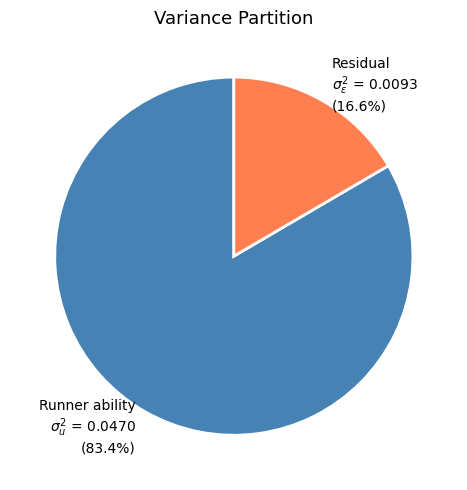

In [ ]:
# --- Variance Components (method-of-moments / ANOVA estimator) ---
#
#   Var(α̂_i) = σ²_u + σ²_ε / n_i   (signal + estimation noise)
#   σ²_u ≈ Var(α̂_i) - σ²_ε × mean(1 / n_i)
#
#   This is the standard ANOVA / Fellner estimator — equivalent to REML when
#   the design is balanced, and very close otherwise.

inv_n_i = 1.0 / runner_cnt  # 1/n_i per runner
correction = sigma2_e * float(np.mean(inv_n_i))  # noise inflation

sigma2_u = max(float(np.var(alpha, ddof=0)) - correction, 0.0)
icc = sigma2_u / (sigma2_u + sigma2_e)

sd_u = np.sqrt(sigma2_u)
print(f"Runner variance   σ²_u = {sigma2_u:.6f}  →  SD = {sd_u:.4f} log-min")
print(
    f"Residual variance σ²_ε = {sigma2_e:.6f}  →  SD = {np.sqrt(sigma2_e):.4f} log-min"
)
print(f"ICC (runner ability explains) = {icc*100:.1f}% of total variance")
print()

print("Runner-ability interpretation (on original time scale):")
print(
    f"  A runner 1 SD *faster* than average: exp(-{sd_u:.4f}) ≈ {np.exp(-sd_u):.3f}×  ({(1-np.exp(-sd_u))*100:.1f}% faster)"
)
print(f"  A runner 1 SD *slower* than average: exp(+{sd_u:.4f}) ≈ {np.exp(+sd_u):.3f}×")

# Pie chart of variance partition
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [sigma2_u, sigma2_e],
    labels=[
        f"Runner ability\n$\\sigma^2_u$ = {sigma2_u:.4f}\n({icc*100:.1f}%)",
        f"Residual\n$\\sigma^2_\\varepsilon$ = {sigma2_e:.4f}\n({(1-icc)*100:.1f}%)",
    ],
    colors=["steelblue", "coral"],
    startangle=90,
    autopct=None,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
ax.set_title("Variance Partition", fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

Total courses estimated: 819
Fastest course: Pegwell Bay parkrun  (-2.6%)
Slowest course: Great Yarmouth North Beach parkrun  (+32.9%)
IQR: +2.5%  –  +6.6%


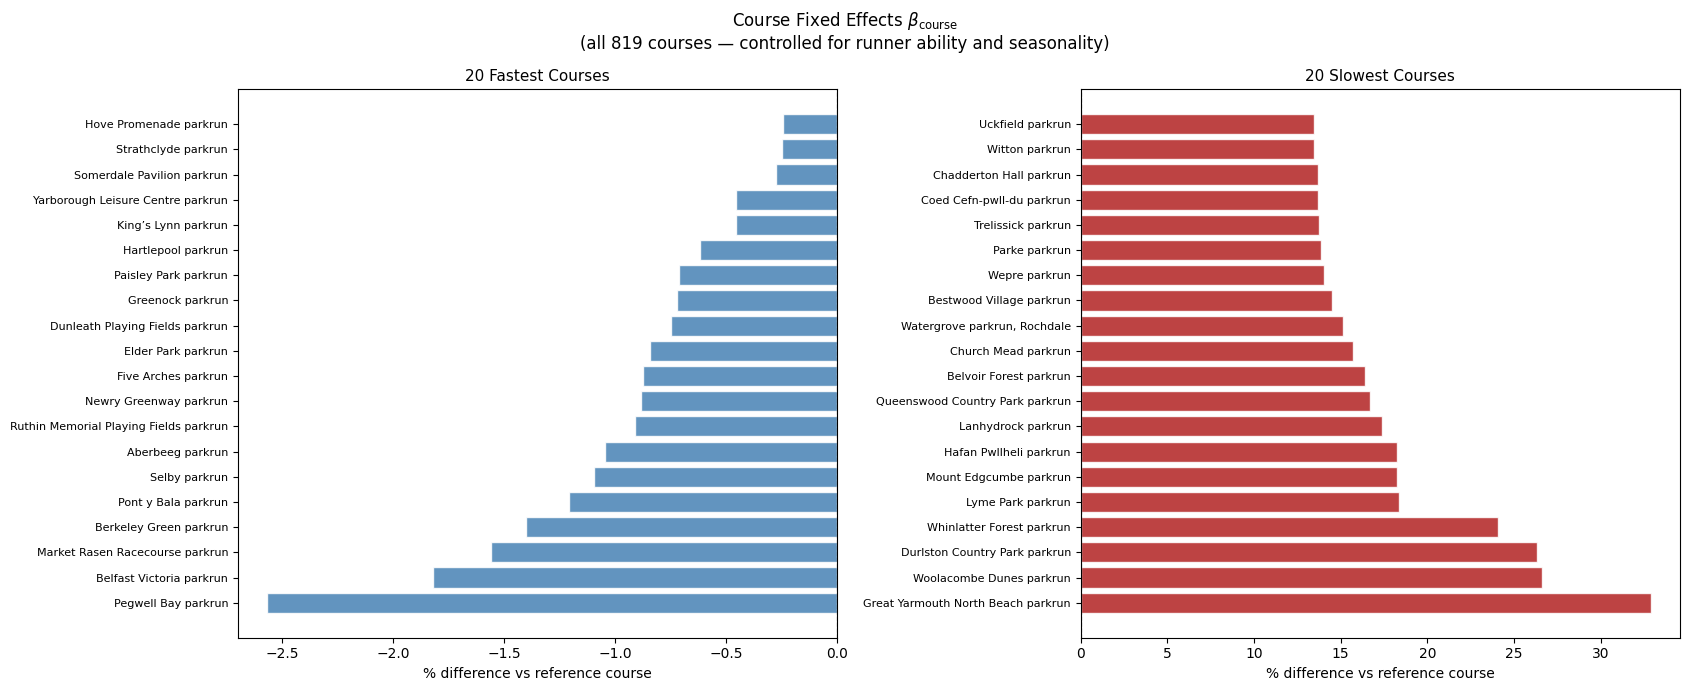

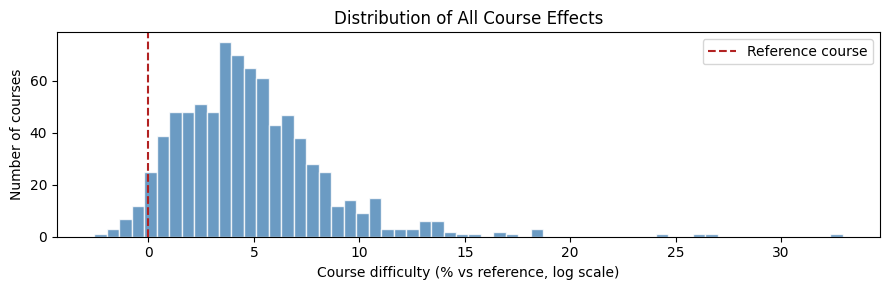

In [ ]:
# --- Course Fixed Effects (β_course) ---
# beta[j] is the log-time coefficient for course j relative to the reference.
# Convert to % difference from reference: (exp(β_j) - 1) × 100

# Build a Series indexed by course name
course_fe_series = pd.Series(beta, index=course_cats)

# Convert to % difference vs reference (ref course is already 0)
all_course_pct = (np.exp(course_fe_series) - 1) * 100
all_course_pct = all_course_pct.sort_values()

print(f"Total courses estimated: {len(all_course_pct):,}")
print(f"Fastest course: {all_course_pct.index[0]}  ({all_course_pct.iloc[0]:+.1f}%)")
print(f"Slowest course: {all_course_pct.index[-1]}  ({all_course_pct.iloc[-1]:+.1f}%)")
print(
    f"IQR: {all_course_pct.quantile(0.25):+.1f}%  –  {all_course_pct.quantile(0.75):+.1f}%"
)

N = 20
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, data, title, color in [
    (axes[0], all_course_pct.head(N), f"{N} Fastest Courses", "steelblue"),
    (axes[1], all_course_pct.tail(N).iloc[::-1], f"{N} Slowest Courses", "firebrick"),
]:
    y_pos = range(len(data))
    ax.barh(y_pos, data.values, color=color, alpha=0.85, edgecolor="white")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(data.index, fontsize=8)
    ax.set_xlabel("% difference vs reference course")
    ax.set_title(title, fontsize=11)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

fig.suptitle(
    "Course Fixed Effects $\\beta_{\\mathrm{course}}$\n"
    f"(all {len(all_course_pct):,} courses — controlled for runner ability and seasonality)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Full distribution of course effects
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(all_course_pct, bins=60, color="steelblue", alpha=0.8, edgecolor="white")
ax.axvline(
    0, color="firebrick", linewidth=1.5, linestyle="--", label="Reference course"
)
ax.set_xlabel("Course difficulty (% vs reference, log scale)")
ax.set_ylabel("Number of courses")
ax.set_title("Distribution of All Course Effects")
ax.legend()
plt.tight_layout()
plt.show()

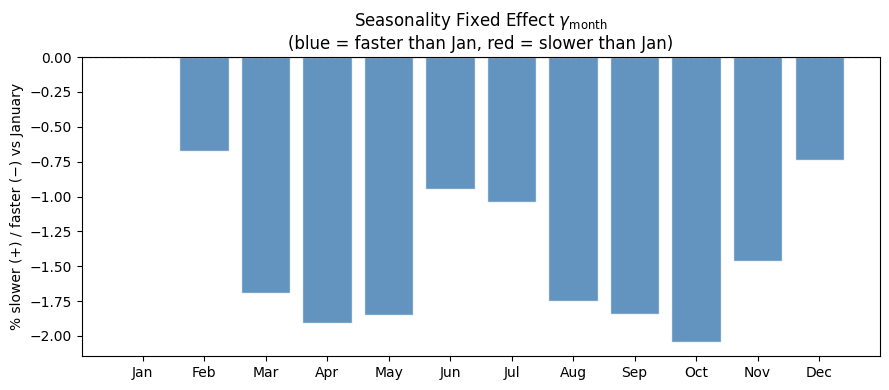

Month effects (% vs January):
  Jan: +0.00%
  Feb: -0.67%
  Mar: -1.69%
  Apr: -1.91%
  May: -1.85%
  Jun: -0.95%
  Jul: -1.04%
  Aug: -1.75%
  Sep: -1.85%
  Oct: -2.04%
  Nov: -1.46%
  Dec: -0.74%


In [29]:
# --- Seasonality Fixed Effects (γ_month) ---
import calendar

month_labels = {str(m).zfill(2): calendar.month_abbr[m] for m in range(1, 13)}

# gamma is already referenced to January (gamma[0]=0 after re-parameterisation)
month_fe_series = pd.Series(gamma, index=month_cats).sort_index()
month_pct = (np.exp(month_fe_series) - 1) * 100  # % vs January
xtick_labels = [month_labels.get(m, m) for m in month_pct.index]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["steelblue" if v <= 0 else "coral" for v in month_pct.values]
ax.bar(
    range(len(month_pct)), month_pct.values, color=colors, alpha=0.85, edgecolor="white"
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(month_pct)))
ax.set_xticklabels(xtick_labels, rotation=0)
ax.set_ylabel("% slower (+) / faster (−) vs January")
ax.set_title(
    "Seasonality Fixed Effect $\\gamma_{\\mathrm{month}}$\n"
    "(blue = faster than Jan, red = slower than Jan)"
)
plt.tight_layout()
plt.show()

print("Month effects (% vs January):")
for m, v in zip(month_pct.index, month_pct.values):
    print(f"  {month_labels.get(m, m)}: {v:+.2f}%")

Runner effects: N = 671,577
  Mean  : 0.000000  (should be ≈ 0)
  Std   : 0.220051  (≈ √σ²_u = 0.216724)
  Skew  : 0.4351
  Kurt  : 0.3238  (excess; 0 = Normal)


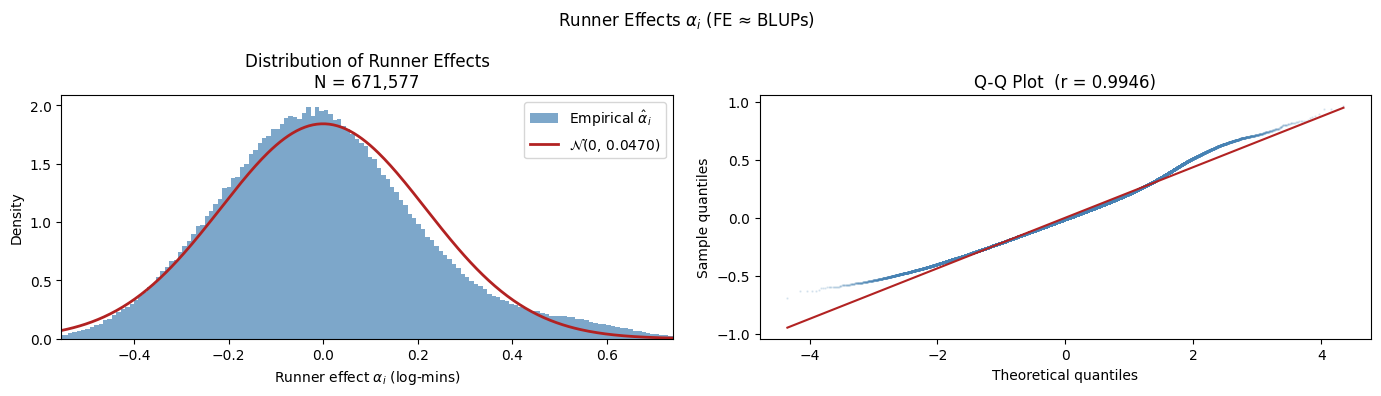

In [30]:
# --- Runner Effects  α_i  (fixed-effect estimates ≈ BLUPs) ---
#
# With ICC ≈ 82%, the Hausman equivalence means FE and BLUP estimates are
# nearly identical for runners with ≥3 observations.
# The FE estimates α_i are slightly noisier than BLUPs for runners with
# few runs, but completely unbiased for the full population.

re_vals = pd.Series(alpha, name="alpha_i")  # mean-zero by construction

print(f"Runner effects: N = {len(re_vals):,}")
print(f"  Mean  : {re_vals.mean():.6f}  (should be ≈ 0)")
print(f"  Std   : {re_vals.std():.6f}  (≈ √σ²_u = {np.sqrt(sigma2_u):.6f})")
print(f"  Skew  : {scipy_stats.skew(re_vals):.4f}")
print(f"  Kurt  : {scipy_stats.kurtosis(re_vals):.4f}  (excess; 0 = Normal)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram with theoretical Normal overlay
x_grid = np.linspace(re_vals.quantile(0.001), re_vals.quantile(0.999), 300)
pdf = scipy_stats.norm.pdf(x_grid, 0, np.sqrt(sigma2_u))

ax = axes[0]
ax.hist(
    re_vals,
    bins=200,
    density=True,
    color="steelblue",
    alpha=0.7,
    edgecolor="none",
    label="Empirical $\\hat{\\alpha}_i$",
)
ax.plot(
    x_grid,
    pdf,
    color="firebrick",
    linewidth=2,
    label=f"$\\mathcal{{N}}(0,\\,{sigma2_u:.4f})$",
)
ax.set_xlim(x_grid[[0, -1]])
ax.set_xlabel("Runner effect $\\alpha_i$ (log-mins)")
ax.set_ylabel("Density")
ax.set_title(f"Distribution of Runner Effects\nN = {len(re_vals):,}")
ax.legend()

# Q-Q plot on a large subsample (Q-Q on 600K+ points is expensive)
qq_sample = re_vals.sample(n=min(100_000, len(re_vals)), random_state=42)
(osm, osr), (slope, intercept_qq, r) = scipy_stats.probplot(qq_sample, dist="norm")
ax = axes[1]
ax.scatter(osm, osr, s=0.5, alpha=0.15, color="steelblue", rasterized=True)
ax.plot(osm, slope * np.array(osm) + intercept_qq, color="firebrick", linewidth=1.5)
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.set_title(f"Q-Q Plot  (r = {r:.4f})")

plt.suptitle("Runner Effects $\\alpha_i$ (FE ≈ BLUPs)", fontsize=12)
plt.tight_layout()
plt.show()

Residuals over 8,225,761 observations
  Mean     : -0.000000  (should be ≈ 0)
  Std      : 0.096589
  Skewness : 2.3183
  Kurtosis : 14.2557  (excess; 0 = Normal)


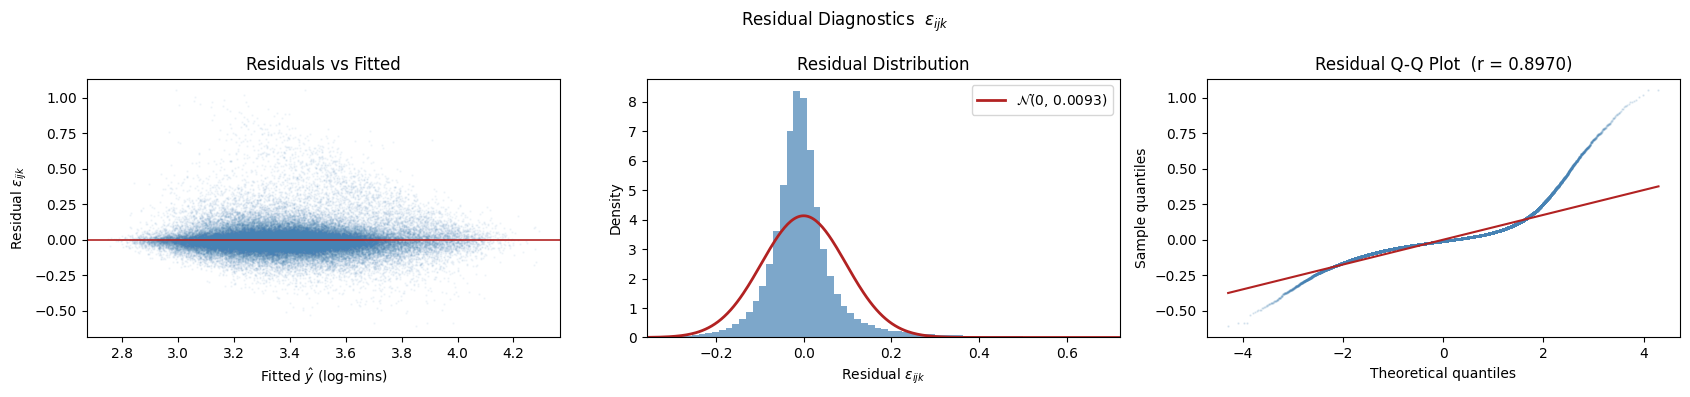

In [32]:
# --- Residual Diagnostics  ε_ijk ---
print(f"Residuals over {len(resid):,} observations")
print(f"  Mean     : {resid.mean():.6f}  (should be ≈ 0)")
print(f"  Std      : {resid.std():.6f}")
print(f"  Skewness : {scipy_stats.skew(resid):.4f}")
print(f"  Kurtosis : {scipy_stats.kurtosis(resid):.4f}  (excess; 0 = Normal)")

# Subsample for scatter/QQ plots — full dataset is too many points to render
rng_plot = np.random.default_rng(1)
plot_mask = rng_plot.choice(len(resid), size=min(80_000, len(resid)), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# 1 — Residuals vs Fitted
ax = axes[0]
ax.scatter(
    fitted[plot_mask],
    resid[plot_mask],
    s=0.5,
    alpha=0.06,
    color="steelblue",
    rasterized=True,
)
ax.axhline(0, color="firebrick", linewidth=1.2)
ax.set_xlabel("Fitted $\\hat{y}$ (log-mins)")
ax.set_ylabel("Residual $\\varepsilon_{ijk}$")
ax.set_title("Residuals vs Fitted")

# 2 — Histogram with Normal overlay
ax = axes[1]
x_grid = np.linspace(np.percentile(resid, 0.1), np.percentile(resid, 99.9), 300)
ax.hist(resid, bins=150, density=True, color="steelblue", alpha=0.7, edgecolor="none")
ax.plot(
    x_grid,
    scipy_stats.norm.pdf(x_grid, 0, np.sqrt(sigma2_e)),
    color="firebrick",
    linewidth=2,
    label=f"$\\mathcal{{N}}(0,\\,{sigma2_e:.4f})$",
)
ax.set_xlim(x_grid[[0, -1]])
ax.set_xlabel("Residual $\\varepsilon_{ijk}$")
ax.set_ylabel("Density")
ax.set_title("Residual Distribution")
ax.legend()

# 3 — Q-Q plot
(osm, osr), (slope, intercept_qq, r) = scipy_stats.probplot(
    resid[plot_mask], dist="norm"
)
ax = axes[2]
ax.scatter(osm, osr, s=0.5, alpha=0.15, color="steelblue", rasterized=True)
ax.plot(osm, slope * np.array(osm) + intercept_qq, color="firebrick", linewidth=1.5)
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.set_title(f"Residual Q-Q Plot  (r = {r:.4f})")

plt.suptitle("Residual Diagnostics  $\\varepsilon_{ijk}$", fontsize=12)
plt.tight_layout()
plt.show()